In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import chi2_contingency
from sklearn.metrics import roc_curve, auc

# Set a global style for plots
sns.set(style="whitegrid")
# (Optional: set font scale for readability)
sns.set_context("talk", font_scale=0.9)

In [3]:
# Load the aggregated binary dataset (already cleaned and renamed)
df_agg = pd.read_csv("meyer_aggregated_binary_renamed.csv")

In [4]:
# Convert factor columns to categorical (since each has fixed levels)
for col in ["moisture", "spring", "displacement", "motor"]:
    df_agg[col] = df_agg[col].astype("category")

print("Data prepared for analysis. Data shape:", df_agg.shape)
df_agg.head()

Data prepared for analysis. Data shape: (1442, 16)


,video,moisture,spring,displacement,motor,U,L_1,L_2,L_3,L_4,C_1,C_2,C_3,C_4,O,X
0,*GH012974,7,2000,0.22,30,0,0,0,0,1,0,1,0,0,1,0
1,*GH012975,7,2000,0.22,30,0,0,0,0,1,0,0,0,1,1,0
2,*GH012976,7,2000,0.22,30,0,0,0,0,1,0,0,1,0,1,0
3,*GH012977,7,2000,0.22,30,0,0,0,0,1,0,0,1,0,1,0
4,*GH012978,7,2000,0.22,30,0,0,0,0,1,0,0,0,1,1,0


In [5]:
# Define a helper function that creates a contingency table for one factor vs. one crack outcome
def chi_square_test(df, factor, outcome):
    """
    Computes a chi-square test of independence between a factor and a binary crack outcome.
    Returns the contingency table, chi-square statistic, degrees of freedom, and p-value.
    """
    # Create contingency table: rows = factor levels, columns = outcome (0 or 1)
    contingency = pd.crosstab(df[factor], df[outcome])
    chi2, p, dof, expected = chi2_contingency(contingency)
    print(f"Chi-Square Test for {outcome} (binary) vs. {factor}:")
    print("Contingency Table:")
    print(contingency)
    print(f"chi2 = {chi2:.4f}, p-value = {p:.6f}, dof = {dof}")
    print("Expected Counts:")
    print(expected, "\n")
    return contingency, chi2, p, dof, expected


# List of factors to test
factors = ["moisture", "spring", "displacement", "motor"]

# List of binary outcomes (crack outcomes)
crack_outcomes = ["U", "L_1", "L_2", "L_3", "L_4", "C_1", "C_2", "C_3", "C_4", "O", "X"]

# Loop through each factor and each outcome, and run the chi-square test.
# (In a publication, you might summarize these results in a table.)
chi_results = {}  # dictionary to store results for possible later use
for factor in factors:
    for outcome in crack_outcomes:
        # Only run the test if the outcome column exists in df_agg.
        if outcome in df_agg.columns:
            print(f"--- Testing {outcome} vs. {factor} ---")
            chi_results[(factor, outcome)] = chi_square_test(df_agg, factor, outcome)

--- Testing U vs. moisture ---
Chi-Square Test for U (binary) vs. moisture:
Contingency Table:
U           0   1
moisture         
5         439  41
7         457  22
9         403  80
chi2 = 40.0974, p-value = 0.000000, dof = 2
Expected Counts:
[[432.39944521  47.60055479]
 [431.49861304  47.50138696]
 [435.10194175  47.89805825]] 

--- Testing L_1 vs. moisture ---
Chi-Square Test for L_1 (binary) vs. moisture:
Contingency Table:
L_1         0  1
moisture        
5         478  2
7         471  8
9         477  6
chi2 = 3.5496, p-value = 0.169520, dof = 2
Expected Counts:
[[474.6740638   5.3259362]
 [473.6851595   5.3148405]
 [477.6407767   5.3592233]] 

--- Testing L_2 vs. moisture ---
Chi-Square Test for L_2 (binary) vs. moisture:
Contingency Table:
L_2         0  1
moisture        
5         479  1
7         470  9
9         475  8
chi2 = 6.4090, p-value = 0.040579, dof = 2
Expected Counts:
[[474.00832178   5.99167822]
 [473.02080444   5.97919556]
 [476.97087379   6.02912621]] 

--

In [6]:
# Fit a separate binary logistic regression model for each crack outcome.
# The model predicts the probability that a video is classified with the crack outcome (1 vs. 0)
# using the experimental factors (moisture, spring, displacement, motor).

# Dictionary to store model summaries
logistic_models = {}

for outcome in crack_outcomes:
    if outcome in df_agg.columns:
        # Build formula: outcome ~ C(moisture) + C(spring) + C(displacement) + C(motor)
        # (The C() wrapper ensures that each predictor is treated as categorical.)
        formula = f"{outcome} ~ C(moisture) + C(spring) + C(displacement) + C(motor)"
        model = smf.glm(formula=formula, data=df_agg, family=sm.families.Binomial()).fit()
        logistic_models[outcome] = model
        print(f"\nLogistic Regression Model for Outcome '{outcome}':")
        print(model.summary())
        # Optionally, you can extract odds ratios:
        odds_ratios = np.exp(model.params)
        print("Odds Ratios:")
        print(odds_ratios)


Logistic Regression Model for Outcome 'U':
                 Generalized Linear Model Regression Results                  
Dep. Variable:                      U   No. Observations:                 1442
Model:                            GLM   Df Residuals:                     1433
Model Family:                Binomial   Df Model:                            8
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -379.65
Date:                Mon, 10 Mar 2025   Deviance:                       759.29
Time:                        03:00:28   Pearson chi2:                 1.15e+03
No. Iterations:                     6   Pseudo R-squ. (CS):             0.1130
Covariance Type:            nonrobust                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------

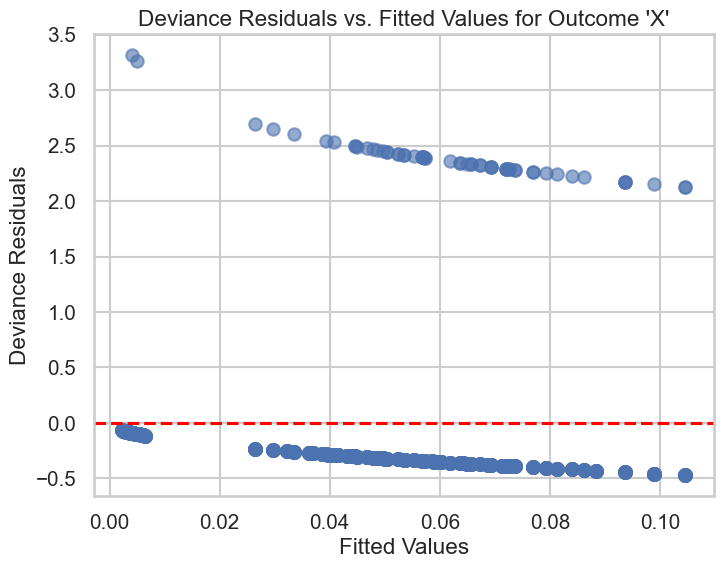

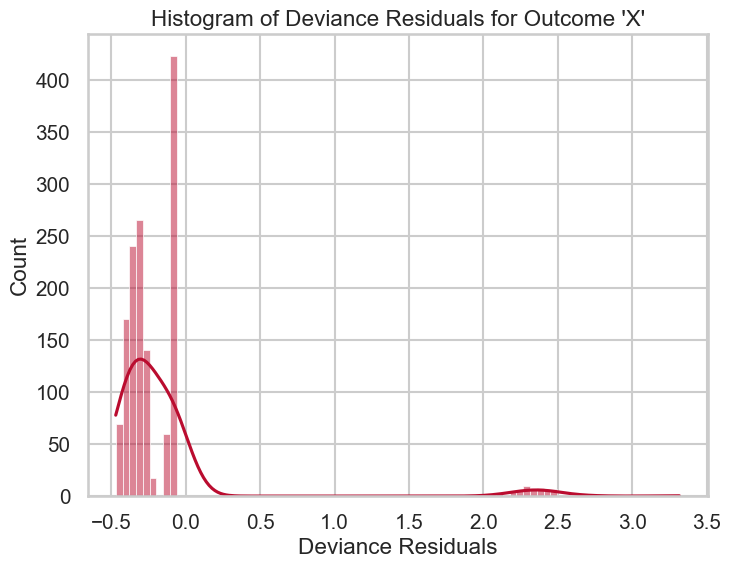

In [7]:
# Example: For one selected outcome (e.g., "X" for Crushed), we conduct model diagnostic plots.
# These diagnostics can include plotting the deviance residuals versus fitted values,
# and checking for influential points. Repeat similar diagnostics for other models as needed.

selected_outcome = "X"
model_X = logistic_models[selected_outcome]

# Extract fitted values and deviance residuals
fitted_vals = model_X.fittedvalues
residuals = model_X.resid_deviance

plt.figure(figsize=(8, 6))
plt.scatter(fitted_vals, residuals, alpha=0.6)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Fitted Values")
plt.ylabel("Deviance Residuals")
plt.title(f"Deviance Residuals vs. Fitted Values for Outcome '{selected_outcome}'")
plt.show()

# Optionally, plot a histogram of the residuals
plt.figure(figsize=(8, 6))
sns.histplot(residuals, kde=True, color="#BA0C2F")
plt.xlabel("Deviance Residuals")
plt.title(f"Histogram of Deviance Residuals for Outcome '{selected_outcome}'")
plt.show()

In [8]:
# Create a composite factor for each pair of factors and plot heatmaps
import os

# Create a folder to save pairwise cross-tab plots
os.makedirs("plots_pairwise", exist_ok=True)

# Define pairwise combinations (all 6 possible pairs)
from itertools import combinations

pairwise_combos = list(combinations(factors, 2))

for fA, fB in pairwise_combos:
    # Create a composite column
    combo_col = f"{fA}_{fB}"
    df_agg[combo_col] = df_agg[fA].astype(str) + "_" + df_agg[fB].astype(str)

    # For each crack outcome, create a pivot table and plot as a heatmap
    for outcome in crack_outcomes:
        pivot_table = df_agg.pivot_table(index=fA, columns=fB, values=outcome, aggfunc="mean") * 100
        plt.figure(figsize=(7, 5))
        sns.heatmap(pivot_table, annot=True, fmt=".2f", cmap="Reds")
        plt.title(f"Heatmap of Mean % '{outcome}' by {fA.capitalize()} vs. {fB.capitalize()}")
        plt.xlabel(fB.capitalize())
        plt.ylabel(fA.capitalize())
        # Save the figure
        plt.savefig(f"plots_pairwise/{combo_col}_{outcome}_heatmap.png", dpi=150, bbox_inches="tight")
        plt.close()

    # Optionally, drop the composite column to keep df_agg clean
    df_agg.drop(columns=[combo_col], inplace=True)

C:\Users\nr77309\AppData\Local\Temp\ipykernel_5448\1348426363.py:19: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_table = df_agg.pivot_table(index=fA, columns=fB, values=outcome, aggfunc="mean") * 100
C:\Users\nr77309\AppData\Local\Temp\ipykernel_5448\1348426363.py:19: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_table = df_agg.pivot_table(index=fA, columns=fB, values=outcome, aggfunc="mean") * 100
C:\Users\nr77309\AppData\Local\Temp\ipykernel_5448\1348426363.py:19: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain 

In [10]:
# Create folders for saving multi-factor combination plots
os.makedirs("plots_triple", exist_ok=True)
os.makedirs("plots_quad", exist_ok=True)

# For triple combinations (e.g., combinations of 3 factors)
from itertools import combinations

triple_combos = list(combinations(factors, 3))


def plot_triple_subplots(df, fA, fB, fC, outcomes, palette):
    """
    Creates subplots for each outcome vs. a composite factor of three factors.
    Saves the figure in a designated folder.
    """
    combo_col = f"{fA}_{fB}_{fC}"
    df[combo_col] = df[fA].astype(str) + "_" + df[fB].astype(str) + "_" + df[fC].astype(str)

    n_outcomes = len(outcomes)
    nrows = int(np.ceil(n_outcomes / 4))
    fig, axes = plt.subplots(nrows, 4, figsize=(18, nrows * 4), sharey=True)
    axes = axes.flatten()

    for i, outcome in enumerate(outcomes):
        grouped_vals = df.groupby(combo_col)[outcome].mean() * 100
        df_reset = grouped_vals.reset_index().sort_values(by=combo_col)
        sns.barplot(x=combo_col, y=outcome, data=df_reset, palette=palette, ax=axes[i])
        axes[i].set_xlabel(f"{fA.capitalize()}_{fB.capitalize()}_{fC.capitalize()} Combo")
        axes[i].set_ylabel(f"% {outcome}")
        axes[i].set_ylim(0, 105)
        axes[i].set_title(f"{outcome}")
        axes[i].tick_params(axis="x", rotation=45)

    # Remove any extra subplots
    for j in range(n_outcomes, len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(f"Triple Factor Summary: {fA.capitalize()}, {fB.capitalize()}, {fC.capitalize()} (All Outcomes)", fontsize=16)
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig(f"plots_triple/{combo_col}_all_outcomes.png", dpi=150, bbox_inches="tight")
    plt.close()

    df.drop(columns=[combo_col], inplace=True)


uga_palette = sns.color_palette(["#BA0C2F", "#D43E5C", "#E38296", "#F0BDC9", "#000000", "#404041", "#717074", "#A7A6A9", "#D7D2CB", "#EED2C0", "#F2F3F4"], n_colors=11)
# Generate triple factor plots for each combination
for fA, fB, fC in triple_combos:
    plot_triple_subplots(df_agg, fA, fB, fC, crack_outcomes, uga_palette)


# For the quadruple (all four factors), we do a similar approach:
def plot_quad_subplots(df, fA, fB, fC, fD, outcomes, palette):
    """
    Creates subplots for each outcome vs. a composite factor of all four factors.
    Saves the figure in a designated folder.
    """
    combo_col = f"{fA}_{fB}_{fC}_{fD}"
    df[combo_col] = df[fA].astype(str) + "_" + df[fB].astype(str) + "_" + df[fC].astype(str) + "_" + df[fD].astype(str)

    n_outcomes = len(outcomes)
    nrows = int(np.ceil(n_outcomes / 4))
    fig, axes = plt.subplots(nrows, 4, figsize=(20, nrows * 4), sharey=True)
    axes = axes.flatten()

    for i, outcome in enumerate(outcomes):
        grouped_vals = df.groupby(combo_col)[outcome].mean() * 100
        df_reset = grouped_vals.reset_index().sort_values(by=combo_col)
        sns.barplot(x=combo_col, y=outcome, data=df_reset, palette=palette, ax=axes[i])
        axes[i].set_xlabel("Combo (Moisture_Spring_Displacement_Motor)")
        axes[i].set_ylabel(f"% {outcome}")
        axes[i].set_ylim(0, 105)
        axes[i].set_title(f"{outcome}")
        axes[i].tick_params(axis="x", rotation=75)

    # Remove extra subplots if any
    for j in range(n_outcomes, len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle("Quadruple Factor Summary: All Factors (Moisture, Spring, Displacement, Motor) - All Outcomes", fontsize=16)
    fig.tight_layout(rect=[0, 0, 1, 0.94])
    os.makedirs("plots_quad", exist_ok=True)
    plt.savefig(f"plots_quad/all_factors_all_outcomes.png", dpi=150, bbox_inches="tight")
    plt.close()

    df.drop(columns=[combo_col], inplace=True)


# Generate quadruple factor plot for all four factors
plot_quad_subplots(df_agg, "moisture", "spring", "displacement", "motor", crack_outcomes, uga_palette)

C:\Users\nr77309\AppData\Local\Temp\ipykernel_5448\2473427059.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=combo_col, y=outcome, data=df_reset, palette=palette, ax=axes[i])
C:\Users\nr77309\AppData\Local\Temp\ipykernel_5448\2473427059.py:27: UserWarning: 
The palette list has fewer values (11) than needed (27) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x=combo_col, y=outcome, data=df_reset, palette=palette, ax=axes[i])
C:\Users\nr77309\AppData\Local\Temp\ipykernel_5448\2473427059.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=combo_col, y=outcome, data=df_reset, palette=palette, ax=axes[i])
C:\Users\nr77309\AppData\Local\Temp\ipykernel_5448\2

C:\Users\nr77309\AppData\Local\Temp\ipykernel_5448\1985754877.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_moisture = df_agg.groupby("moisture")[crack_outcomes].mean() * 100


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Academic\\S8\\Pecan Project\\Paper\\Meyer 1st\\meyer-data-analysis\\plots_stacked\\moisture_stacked.png'

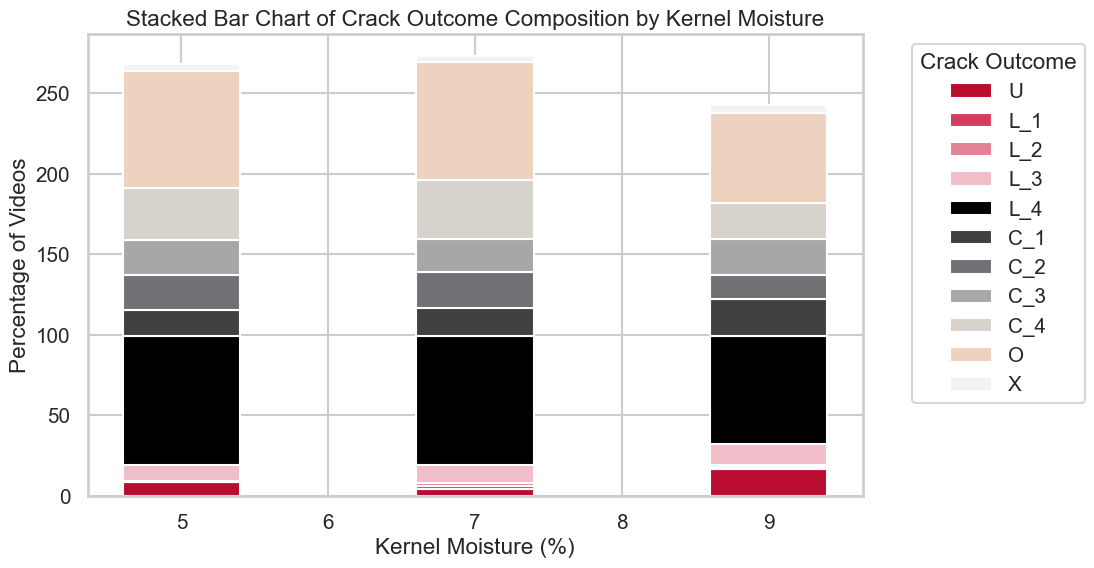

In [11]:
# Alternative: Stacked Bar Chart for Overall Composition by a Factor (e.g., moisture)
# This chart will show, for each moisture level, the stacked percentages of all 11 outcomes.
df_moisture = df_agg.groupby("moisture")[crack_outcomes].mean() * 100
df_moisture = df_moisture.reset_index()

plt.figure(figsize=(10, 6))
bottom = np.zeros(len(df_moisture))
for outcome, color in zip(crack_outcomes, uga_palette):
    plt.bar(df_moisture["moisture"], df_moisture[outcome], bottom=bottom, label=outcome, color=color)
    bottom += df_moisture[outcome]
plt.xlabel("Kernel Moisture (%)")
plt.ylabel("Percentage of Videos")
plt.title("Stacked Bar Chart of Crack Outcome Composition by Kernel Moisture")
plt.legend(title="Crack Outcome", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.savefig("plots_stacked/moisture_stacked.png", dpi=150, bbox_inches="tight")
plt.show()